In [1]:
import pandas as pd

In [2]:
extranjeros = pd.read_csv("data/viajeros_extranjeros.csv")

In [3]:
nacionales = pd.read_csv("data/viajeros_nacionales.csv")

In [4]:
pernoctaciones = pd.read_csv("data/viajeros_pernoctaciones_estancia.csv")

In [5]:
extranjeros.drop('Unnamed: 0', axis=1, inplace=True)
nacionales.drop('Unnamed: 0', axis=1, inplace=True)
pernoctaciones.drop('Unnamed: 0', axis=1, inplace=True)

### pernoctaciones media mensual - España

In [6]:
columns = ['viajeros_total', 'viajeros_esp', 'viajeros_ext', 
           'pernoc_total', 'pernoc_esp', 'pernoc_ext', 
           'estancia_media_total', 'estancia_media_esp', 'estancia_media_ext']

pernoctaciones_espanya_media_mensual = pernoctaciones.groupby(by="month")[columns].mean().reset_index()

### pernoctaciones total anual - España

In [7]:
pernoctaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   periodo               672 non-null    object 
 1   provincia             672 non-null    object 
 2   viajeros_total        672 non-null    int64  
 3   viajeros_esp          672 non-null    int64  
 4   viajeros_ext          672 non-null    int64  
 5   pernoc_total          672 non-null    int64  
 6   pernoc_esp            672 non-null    int64  
 7   pernoc_ext            672 non-null    int64  
 8   estancia_media_total  665 non-null    float64
 9   estancia_media_esp    665 non-null    float64
 10  estancia_media_ext    665 non-null    float64
 11  year                  672 non-null    int64  
 12  month                 672 non-null    int64  
 13  iso_date              672 non-null    object 
dtypes: float64(3), int64(8), object(3)
memory usage: 73.6+ KB


In [8]:
pernoctaciones_espanya_total_anual = pernoctaciones.groupby(by='year')['pernoc_total'].sum().reset_index()

<Axes: >

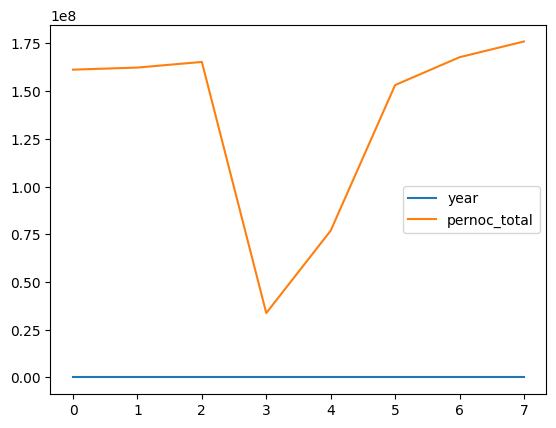

In [9]:
pernoctaciones_espanya_total_anual.plot.line()

### pernoctaciones por fecha - España

In [10]:
pernoctaciones_totales = pernoctaciones[['iso_date', 'viajeros_total', 'pernoc_total', 'estancia_media_total']]

In [11]:
pernoc_espanya_por_fecha = pernoctaciones_totales.groupby(by="iso_date").agg({
    'viajeros_total':'sum',
    'pernoc_total':'sum',
    'estancia_media_total':'mean'
}).reset_index()

In [12]:
pernoc_espanya_por_fecha

,iso_date,viajeros_total,pernoc_total,estancia_media_total
0,2017-01-01,2292273,5147607,2.463325
1,2017-02-01,2604301,5945256,2.466576
2,2017-03-01,3259584,8199455,2.721859
3,2017-04-01,4229618,12146239,2.926875
4,2017-05-01,5140287,16967220,2.964515
...,...,...,...,...
91,2024-08-01,6525412,24398356,3.263586
92,2024-09-01,5891654,20580037,3.134554
93,2024-10-01,5482225,17465589,2.946643
94,2024-11-01,3241974,7488212,2.462562


In [13]:
pernoc_espanya_por_fecha[['iso_date', 'pernoc_total', 'viajeros_total', 'estancia_media_total']].to_csv("data/summaries/pernoctaciones_totales_espanya_por_fecha.csv")

<Axes: >

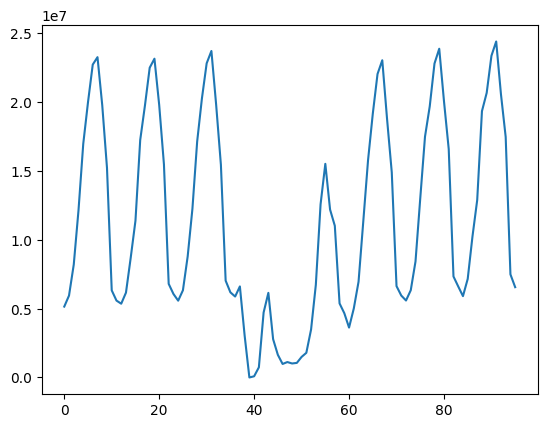

In [14]:
pernoc_espanya_por_fecha.pernoc_total.plot.line()

### pernoctaciones por fecha - Provincias (2022-2024)

In [15]:
pernoctaciones_22_24 = pernoctaciones[pernoctaciones.year.isin([2022, 2023, 2024])]

In [16]:
# Assuming pernoctaciones_22_24 is your DataFrame
crosstab_pernoctaciones_fecha_provincia = pd.crosstab(
    index=pernoctaciones_22_24['iso_date'],
    columns=pernoctaciones_22_24['provincia'],
    values=pernoctaciones_22_24['pernoc_total'],
    aggfunc='mean',  # Use 'sum' to aggregate values; change as needed
    dropna=False    # Optionally include NaN values
)

In [17]:
crosstab_pernoctaciones_fecha_provincia.to_csv("data/summaries/crosstab_pernoctaciones_fecha_provincia_22_24.csv")

In [18]:
crosstab_pernoctaciones_fecha_provincia

provincia,"07 Balears, Illes",08 Barcelona,17 Girona,28 Madrid,29 Málaga,41 Sevilla,46 Valencia/València
iso_date,,,,,,,
2022-01-01,127429.0,996160.0,204903.0,1193236.0,487481.0,320109.0,294104.0
2022-02-01,310405.0,1394900.0,271749.0,1435535.0,783064.0,422782.0,393551.0
2022-03-01,817111.0,1889303.0,317741.0,1720481.0,1153222.0,530313.0,524256.0
2022-04-01,2816016.0,2532973.0,825358.0,2004575.0,1815329.0,629722.0,718645.0
2022-05-01,6377225.0,2917788.0,980345.0,2052491.0,2025618.0,657845.0,759457.0
2022-06-01,8956158.0,3209021.0,1385761.0,2029532.0,2161308.0,611078.0,794544.0
2022-07-01,10386341.0,3679867.0,2068066.0,1922656.0,2529662.0,502287.0,948459.0
2022-08-01,10779452.0,3874913.0,2360768.0,1701671.0,2672820.0,617433.0,1028520.0
2022-09-01,8678063.0,3078699.0,1377674.0,2066264.0,2155199.0,635577.0,807766.0


### pernoctaciones media mensual - Provincias

In [19]:
pernoctaciones.provincia.value_counts()

provincia
29 Málaga               96
41 Sevilla              96
07 Balears, Illes       96
08 Barcelona            96
17 Girona               96
46 Valencia/València    96
28 Madrid               96
Name: count, dtype: int64

In [20]:
pernoctaciones_malaga = pernoctaciones[pernoctaciones.provincia == "29 Málaga"]
pernoctaciones_sevilla = pernoctaciones[pernoctaciones.provincia == "41 Sevilla"]
pernoctaciones_balears = pernoctaciones[pernoctaciones.provincia == "07 Balears, Illes"]
pernoctaciones_barcelona = pernoctaciones[pernoctaciones.provincia == "08 Barcelona"]
pernoctaciones_girona = pernoctaciones[pernoctaciones.provincia == "17 Girona"]
pernoctaciones_valencia = pernoctaciones[pernoctaciones.provincia == "46 Valencia,València"]
pernoctaciones_madrid = pernoctaciones[pernoctaciones.provincia == "28 Madrid"]

#### balears

<Axes: xlabel='month'>

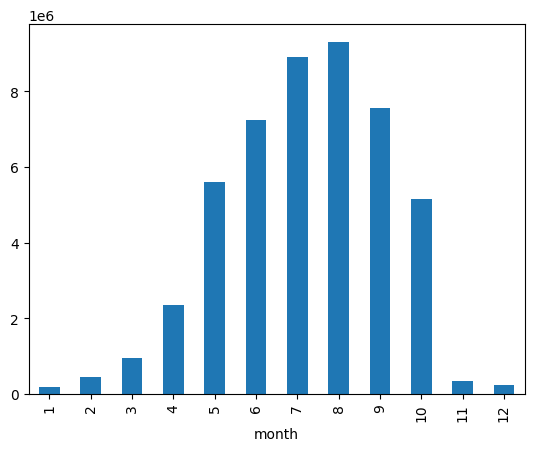

In [21]:
pernoctaciones_balears.groupby(by='month').pernoc_total.mean().plot.bar()

### Extranjeros

In [22]:
extranjeros_2024 = extranjeros[extranjeros.year==2024]

#### visitantes extranjeros  (2024)

In [23]:
extranjeros_2024.groupby(by="pais_origen").viajeros.sum().sort_values(ascending=False).to_frame()

,viajeros
pais_origen,
Total,116166159.0
Residentes en el Extranjero,61846788.0
Residentes en España,54319372.0
UE28 sin España,43143705.0
UE27_2020 sin España,31815931.0
Reino Unido,11327774.0
Alemania,7656443.0
Francia,6551945.0
América (sin EEUU),4725292.0


### visitantes extranjeros por año - países de origen

In [24]:
crosstab_viajeros_anyo_paisdeorigen = pd.crosstab(
    index=extranjeros['year'],
    columns=extranjeros['pais_origen'],
    values=extranjeros['viajeros'],
    aggfunc='sum',  # Aggregate values by sum
    dropna=False    # Optionally include NaN values
)

In [25]:
crosstab_viajeros_anyo_paisdeorigen

pais_origen,Alemania,América (sin EEUU),Asia (sin Japón),Austria,Bélgica,Dinamarca,Estados Unidos de América,Finlandia,Francia,Grecia,...,Residentes en el Extranjero,Resto de la U.E.,Resto del Mundo,Rusia,Suecia,Suiza,Total,UE27_2020 sin España,UE28 sin España,África
year,,,,,,,,,,,,,,,,,,,,,
2017,8014173.0,3308520.0,0.0,462232.0,1380339.0,667873.0,2778123.0,399256.0,5670976.0,121765.0,...,53340899.0,1132260.0,4484695.0,948463.0,1177333.0,1016002.0,103804067.0,0.0,37794134.0,749298.0
2018,7618230.0,3409769.0,0.0,479989.0,1392135.0,663395.0,2963006.0,432524.0,5901146.0,136688.0,...,54145755.0,1190238.0,4813449.0,957946.0,1200634.0,991623.0,105311465.0,0.0,37974307.0,765947.0
2019,7235631.0,3787740.0,0.0,496390.0,1371545.0,632117.0,3409343.0,414827.0,5950546.0,144348.0,...,55981859.0,1316965.0,5142627.0,1031642.0,1109947.0,954793.0,108716047.0,26722568.0,38262320.0,849257.0
2020,1239884.0,796371.0,0.0,76111.0,332664.0,127071.0,378960.0,100884.0,1637590.0,28107.0,...,10894256.0,374196.0,852143.0,142287.0,226195.0,156275.0,34589071.0,6035124.0,7623973.0,256720.0
2021,3085009.0,1293236.0,0.0,193786.0,783530.0,321066.0,871844.0,107588.0,3418911.0,53261.0,...,20451446.0,697598.0,762955.0,132069.0,376985.0,500148.0,60724132.0,13295891.0,15780808.0,324419.0
2022,6592065.0,3592968.0,0.0,480991.0,1383995.0,595536.0,3077786.0,310611.0,6030915.0,134287.0,...,49568084.0,1400133.0,2205164.0,28629.0,773892.0,946084.0,102882568.0,27028518.0,36615431.0,712779.0
2023,7238914.0,4444291.0,0.0,550661.0,1433062.0,608568.0,3952555.0,358542.0,6320146.0,162377.0,...,57283705.0,1662701.0,3231467.0,0.0,849900.0,1050567.0,111991772.0,29908021.0,40568390.0,810576.0
2024,7656443.0,4725292.0,0.0,586582.0,1538185.0,621969.0,4523050.0,377570.0,6551945.0,173551.0,...,61846788.0,1812267.0,3413578.0,0.0,864328.0,1107920.0,116166159.0,31815931.0,43143705.0,906977.0


In [26]:
paises_top = ["Reino Unido", "Francia", "Alemania","Estados Unidos de América", "América (sin EEUU)","Italia", "Países Bajos", "Portugal"]

In [27]:
#crosstab_viajeros_paises_top =
crosstab_viajeros_anyo_paisdeorigen.columns

Index(['Alemania', 'América (sin EEUU)', 'Asia (sin Japón)', 'Austria',
       'Bélgica', 'Dinamarca', 'Estados Unidos de América', 'Finlandia',
       'Francia', 'Grecia', 'Irlanda', 'Italia', 'Japón', 'Luxemburgo',
       'Noruega', 'Otros Países Europeos', 'Países Bajos', 'Polonia',
       'Portugal', 'Reino Unido', 'República Checa', 'Residentes en España',
       'Residentes en el Extranjero', 'Resto de la U.E.', 'Resto del Mundo',
       'Rusia', 'Suecia', 'Suiza', 'Total', 'UE27_2020 sin España',
       'UE28 sin España', 'África'],
      dtype='object', name='pais_origen')

In [28]:
crosstab_viajeros_paises_top.to_csv("data/summaries/crosstab_viajeros_paises_top.csv")

NameError: name 'crosstab_viajeros_paises_top' is not defined

### estancia media por pais de origen

In [ ]:
extranjeros_2024.sort_values(by="estancia_media_total", ascending=False)

,periodo,pais_origen,viajeros,pernoctaciones,estancia_media_total,year,month,iso_date
116,2024M08,Alemania,8475.0,4762987.0,562.004366,2024,8,2024-08-01
323,2024M01,Finlandia,3461.0,226174.0,65.349321,2024,1,2024-01-01
277,2024M03,Noruega,5349.0,321027.0,60.016265,2024,3,2024-03-01
29,2024M11,Alemania,34491.0,2059727.0,59.717810,2024,11,2024-11-01
322,2024M01,Dinamarca,3719.0,212932.0,57.255176,2024,1,2024-01-01
...,...,...,...,...,...,...,...,...
289,2024M03,Asia (sin Japón),NaN,NaN,NaN,2024,3,2024-03-01
308,2024M02,Rusia,NaN,NaN,NaN,2024,2,2024-02-01
318,2024M02,Asia (sin Japón),NaN,NaN,NaN,2024,2,2024-02-01
337,2024M01,Rusia,NaN,NaN,NaN,2024,1,2024-01-01


In [ ]:
extranjeros_2024.describe()

,viajeros,pernoctaciones,estancia_media_total,year,month
count,3.240000e+02,3.240000e+02,324.000000,348.0,348.000000
mean,4.070306e+05,1.706374e+06,8.823284,2024.0,6.500000
std,8.746536e+05,3.893186e+06,32.994816,0.0,3.457023
min,9.420000e+02,2.092000e+03,0.224378,2024.0,1.000000
25%,3.874250e+04,1.725665e+05,2.694273,2024.0,3.750000
50%,1.090955e+05,3.880535e+05,3.991889,2024.0,6.500000
75%,3.062298e+05,9.100570e+05,4.927052,2024.0,9.250000
max,5.497950e+06,2.555016e+07,562.004366,2024.0,12.000000


## Nacionales

In [29]:
nacionales_2024 = nacionales[nacionales.year==2024]

In [55]:
viajeros_cols = [col for col in nacionales_2024.columns if col.startswith('viajeros_')]
viajeros_cols

['viajeros_nacional',
 'viajeros_andalucia',
 'viajeros_aragon',
 'viajeros_asturias',
 'viajeros_balears',
 'viajeros_canarias',
 'viajeros_cantabria',
 'viajeros_castilla_leon',
 'viajeros_castilla_mancha',
 'viajeros_cataluña',
 'viajeros_valencia',
 'viajeros_extremadura',
 'viajeros_galicia',
 'viajeros_madrid',
 'viajeros_murcia',
 'viajeros_navarra',
 'viajeros_pais_vasco',
 'viajeros_rioja',
 'viajeros_ceuta',
 'viajeros_melilla']

In [60]:
# Agrupar por zona y para cada grupo encontrar las 5 columnas con valores más altos
def get_top_5(group):
    # Seleccionar solo columnas de viajeros
    viajeros_data = group[viajeros_cols]
    # Calcular la media por columna y obtener las 5 mayores
    top_5 = viajeros_data.mean().nlargest(6)
    return top_5

top_5_por_zona = nacionales_2024.groupby('zona').apply(get_top_5)

C:\Users\Cristina\AppData\Local\Temp\ipykernel_19424\492539224.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5_por_zona = nacionales_2024.groupby('zona').apply(get_top_5)


In [61]:
top_5_por_zona

zona                                          
07 Balears, Illes     viajeros_nacional           100.000000
                      viajeros_balears             37.066667
                      viajeros_madrid              17.844167
                      viajeros_cataluña            14.453333
                      viajeros_andalucia            8.084167
                      viajeros_valencia             6.655000
08 Barcelona          viajeros_nacional           100.000000
                      viajeros_cataluña            44.300000
                      viajeros_madrid              21.939167
                      viajeros_andalucia            6.612500
                      viajeros_valencia             6.169167
                      viajeros_pais_vasco           3.617500
17 Girona             viajeros_nacional           100.000000
                      viajeros_cataluña            79.668333
                      viajeros_madrid               6.456667
                      viajeros_valenci